In [21]:
from pathlib import Path
import numpy as np
import pandas as pd

DATASET_NAME = "Clean_Dataset.csv"
DATASET_CANDIDATES = [
    Path(DATASET_NAME),
    Path.cwd() / DATASET_NAME,
    Path.cwd() / "data" / DATASET_NAME,
    Path(r"C:\Users\admin\Downloads\archive (5)") / DATASET_NAME,
]
dataset_path = next((path for path in DATASET_CANDIDATES if path.is_file()), None)
if dataset_path is None:
    searched_paths = "\n".join(str(path) for path in DATASET_CANDIDATES)
    raise FileNotFoundError(
        f"Could not find {DATASET_NAME}. Place it beside the notebook or in a data folder.\n"
        f"Searched:\n{searched_paths}"
    )

df = pd.read_csv(dataset_path)
df.columns = df.columns.str.strip()
required_columns = {
    "airline", "source_city", "destination_city", "departure_time",
    "arrival_time", "stops", "class", "duration", "days_left", "price",
}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

print(f"Loaded {len(df):,} rows and {len(df.columns):,} columns from {dataset_path}")
display(df.head())

Loaded 300,153 rows and 12 columns from C:\Users\admin\Downloads\archive (5)\Clean_Dataset.csv


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [22]:
df.tail(5)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 42.9 MB


In [24]:
# Remove exported row indexes; keep legitimate flight attributes for EDA.
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df["price"] = pd.to_numeric(df["price"], errors="coerce")
invalid_target = df["price"].isna() | (df["price"] < 0)
print(f"Rows excluded for missing/negative price: {invalid_target.sum():,}")
df = df.loc[~invalid_target].copy()

for column in df.select_dtypes(include=["object", "string"]).columns:
    df[column] = df[column].astype("string").str.strip().replace("", pd.NA)

Rows excluded for missing/negative price: 0


In [25]:
print(df.columns.tolist())

['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


In [26]:
print("Potential exported index columns:", [
    column for column in df.columns if column.lower().startswith("unnamed")
])

Potential exported index columns: []


In [27]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (300153, 11)

Columns:
['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']

Data Types:
airline              string
flight               string
source_city          string
departure_time       string
stops                string
arrival_time         string
destination_city     string
class                string
duration            float64
days_left             int64
price                 int64
dtype: object


In [28]:
missing_values = df.isnull().sum()

print(missing_values)

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [29]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

print(missing_table)

                  Missing Values  Missing Percentage
airline                        0                 0.0
flight                         0                 0.0
source_city                    0                 0.0
departure_time                 0                 0.0
stops                          0                 0.0
arrival_time                   0                 0.0
destination_city               0                 0.0
class                          0                 0.0
duration                       0                 0.0
days_left                      0                 0.0
price                          0                 0.0


In [30]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [31]:
# Exact duplicate records may be repeated fare observations; report them without
# silently changing the target distribution.
print(f"Exact duplicate rows (retained): {df.duplicated().sum():,}")
print(f"Analysis rows: {len(df):,}")

Exact duplicate rows (retained): 0
Analysis rows: 300,153


In [32]:
print(df["price"].describe())

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64


In [33]:
print("Minimum price:", df["price"].min())
print("Maximum price:", df["price"].max())

Minimum price: 1105
Maximum price: 123071


In [34]:
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for col in categorical_columns:
    print(f"\n{col} (top 10 categories)")
    print(df[col].value_counts(dropna=False).head(10))


airline (top 10 categories)
airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64[pyarrow]

flight (top 10 categories)
flight
UK-706    3235
UK-772    2741
UK-720    2650
UK-836    2542
UK-822    2468
UK-828    2440
UK-874    2423
UK-832    2404
UK-826    2335
UK-860    2329
Name: count, dtype: int64[pyarrow]

source_city (top 10 categories)
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64[pyarrow]

departure_time (top 10 categories)
departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64[pyarrow]

stops (top 10 categories)
stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64[pyarrow]

arrival_time (top 10 categories)
ar

In [35]:
# The supplied duration is measured in hours. Preserve a model-friendly minute feature.
duration_hours = pd.to_numeric(df["duration"], errors="coerce")
df["duration_minutes"] = duration_hours * 60
df = df.drop(columns=["duration"], errors="ignore")
df["route"] = (
    df["source_city"].fillna("Unknown").astype(str)
    + " -> "
    + df["destination_city"].fillna("Unknown").astype(str)
)

numeric_columns = df.select_dtypes(include="number").columns.tolist()
numeric_summary = df[numeric_columns].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
).T
numeric_summary["missing"] = df[numeric_columns].isna().sum()
numeric_summary["unique"] = df[numeric_columns].nunique()
numeric_summary["skew"] = df[numeric_columns].skew()
numeric_summary["iqr_outlier_count"] = [
    ((df[column] < numeric_summary.loc[column, "25%"] - 1.5 * (numeric_summary.loc[column, "75%"] - numeric_summary.loc[column, "25%"]))
     | (df[column] > numeric_summary.loc[column, "75%"] + 1.5 * (numeric_summary.loc[column, "75%"] - numeric_summary.loc[column, "25%"]))
    ).sum()
    for column in numeric_columns
]
display(numeric_summary.round(2))

,count,mean,std,min,1%,25%,50%,75%,99%,max,missing,unique,skew,iqr_outlier_count
days_left,300153.0,26.00,13.56,1.0,2.0,15.0,26.0,38.0,49.0,49.0,0,49,-0.04,0
price,300153.0,20889.66,22697.77,1105.0,1776.0,4783.0,7425.0,42521.0,76736.0,123071.0,0,12157,1.06,123
duration_minutes,300153.0,733.26,431.52,49.8,79.8,409.8,675.0,970.2,1744.8,2989.8,0,476,0.60,2110


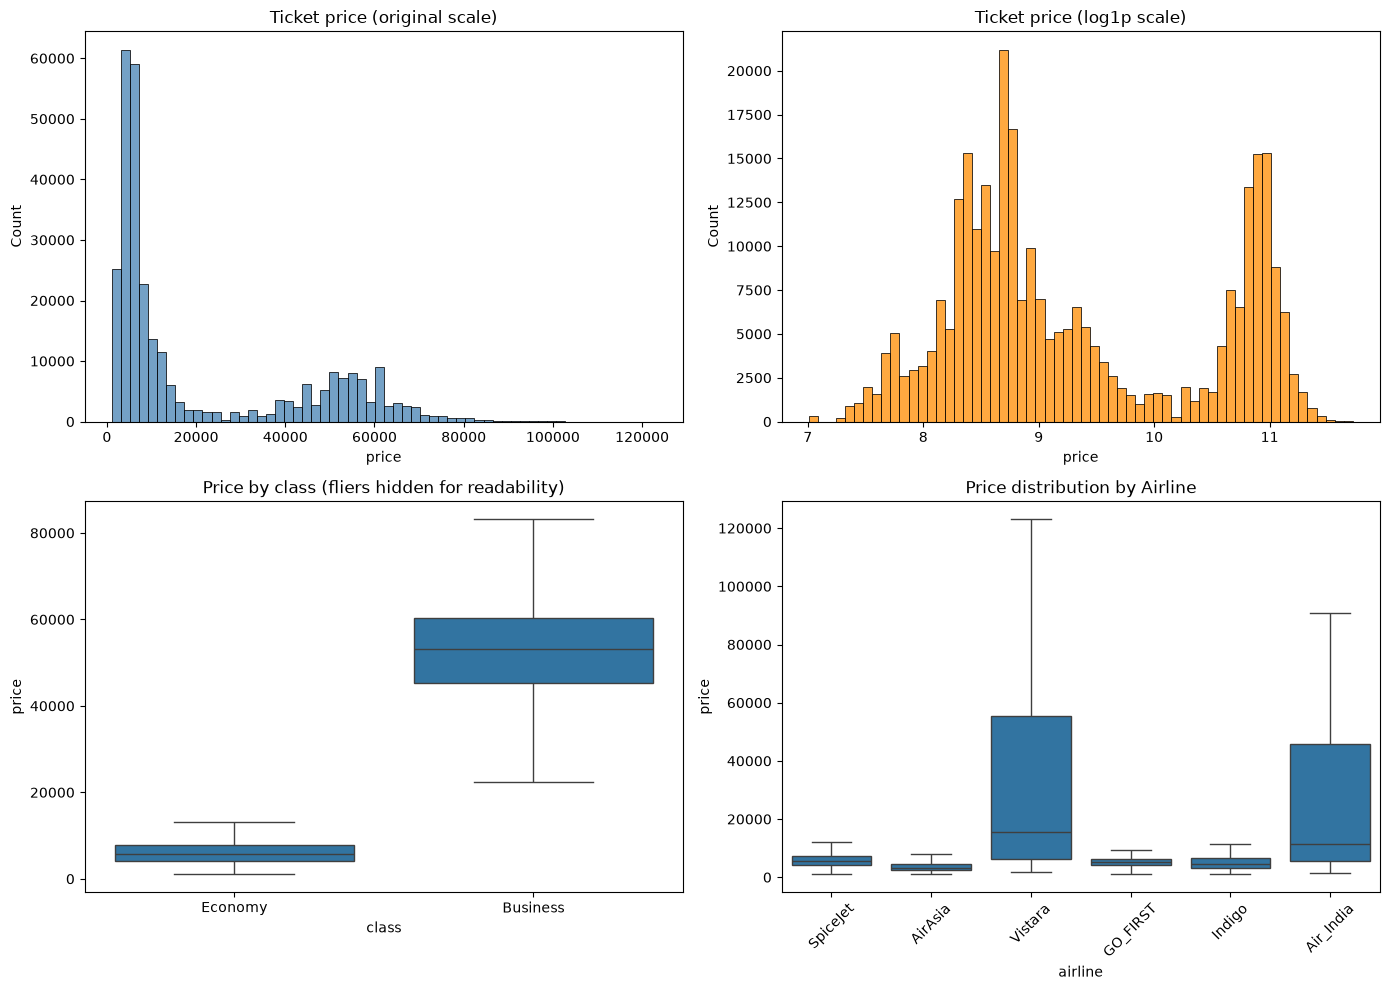

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

price = df['price']

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Original Price Distribution
sns.histplot(price, bins=60, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Ticket price (original scale)")

# 2. Log-transformed Price Distribution
sns.histplot(np.log1p(price), bins=60, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Ticket price (log1p scale)")

# 3. Price distribution by Class
sns.boxplot(data=df, x="class", y="price", ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title("Price by class (fliers hidden for readability)")

# 4. Price distribution by Airline (Fills the blank bottom-right plot!)
sns.boxplot(data=df, x="airline", y="price", ax=axes[1, 1], showfliers=False)
axes[1, 1].set_title("Price distribution by Airline")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_columns].nunique(dropna=True),
    "missing": df[categorical_columns].isna().sum(),
    "top_value": [df[column].mode(dropna=True).iloc[0] if df[column].notna().any() else pd.NA
                  for column in categorical_columns],
})
display(categorical_summary.sort_values("unique_values", ascending=False))

for column in ["class", "airline", "stops", "departure_time", "arrival_time"]:
    if column in df.columns:
        print(f"\n{column} counts (top 12):")
        display(df[column].value_counts(dropna=False).head(12).to_frame("rows"))

,unique_values,missing,top_value
flight,1561,0,UK-706
route,30,0,Delhi -> Mumbai
airline,6,0,Vistara
departure_time,6,0,Morning
source_city,6,0,Delhi
destination_city,6,0,Mumbai
arrival_time,6,0,Night
stops,3,0,one
class,2,0,Economy



class counts (top 12):


,rows
class,
Economy,206666
Business,93487



airline counts (top 12):


,rows
airline,
Vistara,127859
Air_India,80892
Indigo,43120
GO_FIRST,23173
AirAsia,16098
SpiceJet,9011


...

,rows
stops,
one,250863
zero,36004
two_or_more,13286



departure_time counts (top 12):


,rows
departure_time,
Morning,71146
Early_Morning,66790
Evening,65102
Night,48015
Afternoon,47794
Late_Night,1306



arrival_time counts (top 12):


,rows
arrival_time,
Night,91538
Evening,78323
Morning,62735
Afternoon,38139
Early_Morning,15417
Late_Night,14001


In [2]:
import os
import pandas as pd

# Let's search for CSV files in your current working directory and subdirectories
print("Current Working Directory:", os.getcwd())
print("\nCSV files found nearby:")
for root, dirs, files in os.walk("."):
  for file in files:
    if file.endswith(".csv"):
      print(os.path.join(root, file))

Current Working Directory: d:\faeature eng\EDA

CSV files found nearby:


In [9]:
import pandas as pd

# Path to your actual dataset found in Downloads
file_path = r'C:\Users\admin\Downloads\archive (5)\Clean_Dataset.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Print unique origin and destination cities
source_cities = df['source_city'].unique().tolist()
dest_cities = df['destination_city'].unique().tolist()

print("--------------------------------------------------")
print(f"Total Rows Loaded: {len(df):,}")
print("Source Cities:", source_cities)
print("Destination Cities:", dest_cities)
print("--------------------------------------------------")

--------------------------------------------------
Total Rows Loaded: 300,153
Source Cities: ['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Destination Cities: ['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
--------------------------------------------------


In [ ]:
# Keep target separate and exclude flight identifiers to reduce memorization.
identifier_columns = [column for column in ["flight", "flight_no", "Unnamed: 0"] if column in df.columns]
X = df.drop(columns=["price", *identifier_columns])
y = df["price"].astype(float)
print(f"Feature rows/columns: {X.shape}; target rows: {len(y):,}")
print("Excluded identifiers:", identifier_columns)

Feature rows/columns: (300153, 10); target rows: 300,153
Excluded identifiers: ['flight']


In [ ]:
from sklearn.model_selection import train_test_split

# Stratify by target quantiles so the held-out set retains the fare range.
target_strata = pd.qcut(y.rank(method="first"), q=10, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=target_strata
)
print(f"Train: {len(X_train):,} rows; test: {len(X_test):,} rows")
print(f"Train target range: {y_train.min():,.0f} to {y_train.max():,.0f}")
print(f"Test target range:  {y_test.min():,.0f} to {y_test.max():,.0f}")

Train: 240,122 rows; test: 60,031 rows
Train target range: 1,105 to 123,071
Test target range:  1,105 to 116,562


In [ ]:
numeric_model_columns = X_train.select_dtypes(include="number").columns.tolist()
categorical_model_columns = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numeric features:", numeric_model_columns)
print("Categorical features:", categorical_model_columns)

Numeric features: ['days_left', 'duration_minutes']
Categorical features: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']


In [ ]:
print("Numeric feature count:", len(numeric_model_columns))
print("Categorical feature count:", len(categorical_model_columns))

Numeric feature count: 2
Categorical feature count: 7


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [ ]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore", sparse_output=True, dtype=np.float32
    ))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_model_columns),
    ("categorical", categorical_pipeline, categorical_model_columns)
], sparse_threshold=1.0)

In [ ]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

In [ ]:
print("Fitted preprocessor feature count:", len(preprocessor.get_feature_names_out()))
print("First transformed feature names:", preprocessor.get_feature_names_out()[:10])

Fitted preprocessor feature count: 37
First transformed feature names: ['numeric__days_left' 'numeric__duration_minutes'
 'categorical__airline_AirAsia' 'categorical__airline_Air_India'
 'categorical__airline_GO_FIRST' 'categorical__airline_Indigo'
 'categorical__airline_SpiceJet' 'categorical__airline_Vistara'
 'categorical__source_city_Bangalore' 'categorical__source_city_Chennai']


In [ ]:
import numpy as np

print("Training shape:", X_train_encoded.shape)
print("Testing shape:", X_test_encoded.shape)

print(
    "All values numerical:",
    np.issubdtype(X_train_encoded.dtype, np.number)
)

Training shape: (240122, 37)
Testing shape: (60031, 37)
All values numerical: True


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_encoded, y_train)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compare training and held-out test performance to check for overfitting.
y_train_pred = model.predict(X_train_encoded)
y_test_pred = model.predict(X_test_encoded)

evaluation = pd.DataFrame(
    {
        "MAE": [
            mean_absolute_error(y_train, y_train_pred),
            mean_absolute_error(y_test, y_test_pred),
        ],
        "RMSE": [
            mean_squared_error(y_train, y_train_pred) ** 0.5,
            mean_squared_error(y_test, y_test_pred) ** 0.5,
        ],
        "R2": [
            r2_score(y_train, y_train_pred),
            r2_score(y_test, y_test_pred),
        ],
    },
    index=["train", "test"],
)

evaluation.round(3)

,MAE,RMSE,R2
train,415.866,1119.640,0.998
test,1075.348,2782.125,0.985


In [ ]:
y_pred = model.predict(X_test_encoded)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1075.3476910942754
RMSE: 2782.125403533787
R²  : 0.9849845044963434


In [ ]:
# Regression prices are continuous, so balance price ranges with training weights, not SMOTE.
# Fixed-width target bands let rare price ranges receive more training weight.
price_bin_edges = np.linspace(float(y_train.min()), float(y_train.max()), 9)
price_bin_edges[0] = np.nextafter(price_bin_edges[0], -np.inf)
price_bin_edges[-1] = np.nextafter(price_bin_edges[-1], np.inf)
price_band_train = pd.cut(y_train, bins=price_bin_edges, include_lowest=True)
price_band_counts = price_band_train.value_counts().sort_index()
train_band_counts = price_band_train.map(price_band_counts)
sample_weight = 1 / train_band_counts.to_numpy(dtype=float)
sample_weight /= sample_weight.mean()
training_band_summary = pd.DataFrame(
    {
        "training_rows": price_band_counts,
        "mean_sample_weight": pd.Series(sample_weight, index=y_train.index).groupby(
            price_band_train, observed=False
        ).mean(),
    }
)
display(training_band_summary.round(3))


balanced_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
balanced_model.fit(X_train_encoded, y_train, sample_weight=sample_weight)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_test_pred = model.predict(X_test_encoded)
balanced_test_pred = balanced_model.predict(X_test_encoded)

model_comparison = pd.DataFrame(
    {
        "MAE": [
            mean_absolute_error(y_test, baseline_test_pred),
            mean_absolute_error(y_test, balanced_test_pred),
        ],
        "RMSE": [
            mean_squared_error(y_test, baseline_test_pred) ** 0.5,
            mean_squared_error(y_test, balanced_test_pred) ** 0.5,
        ],
        "R2": [
            r2_score(y_test, baseline_test_pred),
            r2_score(y_test, balanced_test_pred),
        ],
    },
    index=["baseline", "price_weighted"],
)
display(model_comparison.round(3))

test_price_band = pd.cut(y_test, bins=price_bin_edges, include_lowest=True)
band_comparison = pd.DataFrame(
    {
        "test_rows": y_test.groupby(test_price_band, observed=False).size(),
        "baseline_MAE": (y_test - baseline_test_pred).abs().groupby(
            test_price_band, observed=False
        ).mean(),
        "weighted_MAE": (y_test - balanced_test_pred).abs().groupby(
            test_price_band, observed=False
        ).mean(),
    }
)
display(band_comparison.round(2))

,training_rows,mean_sample_weight
price,,
"(1104.999, 16350.75]",161381,0.186
"(16350.75, 31596.5]",9049,3.317
"(31596.5, 46842.25]",16747,1.792
"(46842.25, 62088.0]",39458,0.761
"(62088.0, 77333.75]",11297,2.657
"(77333.75, 92579.5]",1955,15.353
"(92579.5, 107825.25]",217,138.319
"(107825.25, 123071.0]",18,1667.514


,MAE,RMSE,R2
baseline,1075.348,2782.125,0.985
price_weighted,1375.906,3153.319,0.981


,test_rows,baseline_MAE,weighted_MAE
price,,,
"(1104.999, 16350.75]",40352,520.62,864.73
"(16350.75, 31596.5]",2202,2120.66,1766.09
"(31596.5, 46842.25]",4245,1122.60,1253.83
"(46842.25, 62088.0]",9903,1646.86,2170.56
"(62088.0, 77333.75]",2765,4211.02,4054.14
"(77333.75, 92579.5]",486,9929.03,9284.08
"(92579.5, 107825.25]",72,16820.58,15703.18
"(107825.25, 123071.0]",6,20380.76,24123.75


In [ ]:
import pandas as pd
import numpy as np

# 1. First, load your dataset
df = pd.read_csv(r"C:\Users\admin\Downloads\archive (6)\Freshly_cleaned.csv")

# 2. Check column names to make sure Date_of_Journey exists
print("Columns in your dataset:", df.columns.tolist())

# Display the first 5 rows
df.head()

Columns in your dataset: ['Unnamed: 0', 'airline', 'from', 'to', 'price', 'class_category', 'class', 'day', 'month', 'flight_no', 'route', 'dep_hour', 'arr_hour', 'dep_period', 'arr_period', 'airline_index', 'route_index', 'duration_in_min', 'stops', 'stops_category', 'arr_daytime', 'arr_daytime_category', 'dep_daytime', 'dep_daytime_category', 'month_category']


,Unnamed: 0,airline,from,to,price,class_category,class,day,month,flight_no,...,airline_index,route_index,duration_in_min,stops,stops_category,arr_daytime,arr_daytime_category,dep_daytime,dep_daytime_category,month_category
0,0,SpiceJet,Delhi,Mumbai,5953,Economy,0,11,2,SG-8709,...,4,14,130,0,Non-stop,0,Night Arrival,1,Daytime Departure,February
1,1,SpiceJet,Delhi,Mumbai,5953,Economy,0,11,2,SG-8157,...,4,14,140,0,Non-stop,1,Daytime Arrival,1,Daytime Departure,February
2,2,AirAsia,Delhi,Mumbai,5956,Economy,0,11,2,I5-764,...,1,14,130,0,Non-stop,1,Daytime Arrival,0,Night Departure,February
3,3,Vistara,Delhi,Mumbai,5955,Economy,0,11,2,UK-995,...,7,14,135,0,Non-stop,1,Daytime Arrival,1,Daytime Departure,February
4,4,Vistara,Delhi,Mumbai,5955,Economy,0,11,2,UK-963,...,7,14,140,0,Non-stop,1,Daytime Arrival,1,Daytime Departure,February


In [ ]:
# Drop index and raw ID columns
cols_to_drop = ['Unnamed: 0', 'flight_no']

# Drop if they exist in dataframe
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [ ]:
# Identify non-numeric (object) columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Encoding categorical columns:", categorical_cols)

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Encoding categorical columns: ['airline', 'from', 'to', 'class_category', 'route', 'dep_period', 'arr_period', 'stops_category', 'arr_daytime_category', 'dep_daytime_category', 'month_category']


C:\Users\admin\AppData\Local\Temp\ipykernel_29116\1541790007.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [ ]:
import numpy as np

# Separate features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = np.log1p(df_encoded['price']) # Log transform price

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Make predictions and convert back from Log scale
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# Print metrics
print("Mean Absolute Error (MAE):", round(mean_absolute_error(y_actual, y_pred), 2))
print("R2 Score (Accuracy):", round(r2_score(y_actual, y_pred), 4))

Mean Absolute Error (MAE): 938.18
R2 Score (Accuracy): 0.9883


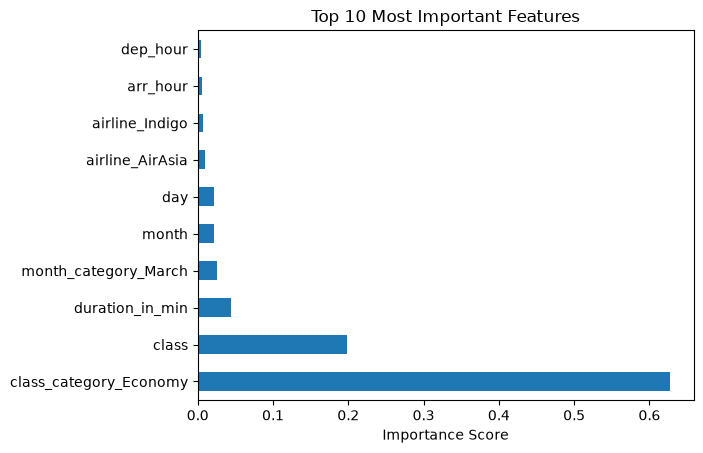

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.show()

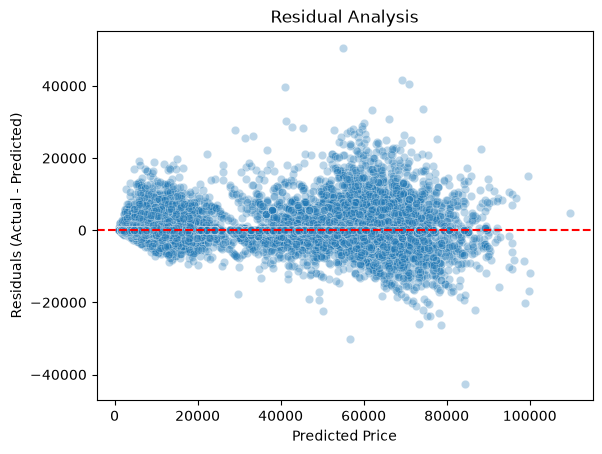

In [ ]:
import seaborn as sns

residuals = y_actual - y_pred
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Analysis")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "flight_price_rf_model.pkl")

['flight_price_rf_model.pkl']

In [ ]:
# Evaluate model performance on training data
y_pred_train = np.expm1(model.predict(X_train))
y_train_actual = np.expm1(y_train)

print("Train MAE:", round(mean_absolute_error(y_train_actual, y_pred_train), 2))
print("Test MAE: ", round(mean_absolute_error(y_actual, y_pred), 2))
print("Train R2: ", round(r2_score(y_train_actual, y_pred_train), 4))
print("Test R2:  ", round(r2_score(y_actual, y_pred), 4))

Train MAE: 366.67
Test MAE:  938.18
Train R2:  0.998
Test R2:   0.9883


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Train a regularized Random Forest model to prevent deep-tree memorization
regularized_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,           # Limits tree depth to control overfitting
    min_samples_split=5,     # Requires at least 5 samples to split a node
    min_samples_leaf=2,      # Requires at least 2 samples per leaf node
    random_state=42,
    n_jobs=-1
)

regularized_model.fit(X_train, y_train)

# Evaluate on Train and Test
y_train_pred = np.expm1(regularized_model.predict(X_train))
y_test_pred = np.expm1(regularized_model.predict(X_test))

print("New Train MAE:", round(mean_absolute_error(np.expm1(y_train), y_train_pred), 2))
print("New Test MAE: ", round(mean_absolute_error(np.expm1(y_test), y_test_pred), 2))
print("New Train R2: ", round(r2_score(np.expm1(y_train), y_train_pred), 4))
print("New Test R2:  ", round(r2_score(np.expm1(y_test), y_test_pred), 4))

New Train MAE: 1617.8
New Test MAE:  1718.59
New Train R2:  0.9793
New Test R2:   0.977


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# A balanced model: slightly deeper trees and fewer leaf restrictions
balanced_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=25,           # Allows deeper learning without total restriction
    min_samples_split=2,     # Standard split requirement
    min_samples_leaf=1,      # Allows individual leaf tailoring
    random_state=42,
    n_jobs=-1
)

balanced_model.fit(X_train, y_train)

# Evaluate
y_train_pred = np.expm1(balanced_model.predict(X_train))
y_test_pred = np.expm1(balanced_model.predict(X_test))

print("Balanced Train MAE:", round(mean_absolute_error(np.expm1(y_train), y_train_pred), 2))
print("Balanced Test MAE: ", round(mean_absolute_error(np.expm1(y_test), y_test_pred), 2))
print("Balanced Train R2: ", round(r2_score(np.expm1(y_train), y_train_pred), 4))
print("Balanced Test R2:  ", round(r2_score(np.expm1(y_test), y_test_pred), 4))

Balanced Train MAE: 578.76
Balanced Test MAE:  1035.03
Balanced Train R2:  0.9964
Balanced Test R2:   0.9879


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# A balanced model: slightly deeper trees and fewer leaf restrictions
balanced_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=25,           # Allows deeper learning without total restriction
    min_samples_split=2,     # Standard split requirement
    min_samples_leaf=1,      # Allows individual leaf tailoring
    random_state=42,
    n_jobs=-1
)

balanced_model.fit(X_train, y_train)

# Evaluate
y_train_pred = np.expm1(balanced_model.predict(X_train))
y_test_pred = np.expm1(balanced_model.predict(X_test))

print("Balanced Train MAE:", round(mean_absolute_error(np.expm1(y_train), y_train_pred), 2))
print("Balanced Test MAE: ", round(mean_absolute_error(np.expm1(y_test), y_test_pred), 2))
print("Balanced Train R2: ", round(r2_score(np.expm1(y_train), y_train_pred), 4))
print("Balanced Test R2:  ", round(r2_score(np.expm1(y_test), y_test_pred), 4))

Balanced Train MAE: 578.76
Balanced Test MAE:  1035.03
Balanced Train R2:  0.9964
Balanced Test R2:   0.9879


In [39]:
import sys
print(sys.executable)

c:\Users\admin\AppData\Local\Programs\Python\Python314\python.exe


In [40]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 970.1 kB/s eta 0:00:50
    --------------------------------------- 0.8/48.9 MB 891.5 kB/s eta 0:00:55
    --------------------------------------- 1.0/48.9 MB 1.0 MB/s eta 0:00:48
   - -------------------------------------- 1.3/48.9 MB 1.1 MB/s eta 0:00:46
   - -------------------------------------- 1.6/48.9 MB 1.1 MB/s eta 0:00:44
   - -------------------------------------- 1.8/48.9 MB 1.1 MB/s eta 0:00:42
   - -------------------------------------- 2.1/48.9 MB 1.2 MB/s eta 0:00:40
   - -------------------------------------- 2.4/48.9 MB 1.2 MB/s eta 0:00:39
   -- ------------------------------------- 2.6/48.9 MB 1.2 MB/s eta 0:00:38
   -- -----------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import numpy as np
from pandas.api.types import is_bool_dtype

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor


# Check that train and test feature columns match.
if not X_train.columns.is_unique:
    raise ValueError("X_train has duplicate column names.")

if set(X_train.columns) != set(X_test.columns):
    raise ValueError("X_train and X_test must contain the same feature columns.")

X_train = X_train.copy()
X_test = X_test.loc[:, X_train.columns].copy()

# Convert boolean features to numeric 0/1, including nullable boolean columns.
bool_features = [
    col for col in X_train.columns
    if is_bool_dtype(X_train[col].dtype)
]

for col in bool_features:
    X_train[col] = X_train[col].map({True: 1.0, False: 0.0})
    X_test[col] = X_test[col].map({True: 1.0, False: 0.0})

# Split features by type.
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

if not numeric_features and not categorical_features:
    raise ValueError("No feature columns found in X_train.")

# Convert targets to 1D numeric arrays.
y_train_log = np.asarray(y_train, dtype=float).reshape(-1)
y_test_log = np.asarray(y_test, dtype=float).reshape(-1)

if len(y_train_log) != len(X_train) or len(y_test_log) != len(X_test):
    raise ValueError("Feature and target row counts do not match.")

if not np.isfinite(y_train_log).all() or not np.isfinite(y_test_log).all():
    raise ValueError("Targets contain missing or infinite values.")

# Preprocess numeric and categorical columns separately.
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

transformers = []

if numeric_features:
    transformers.append(("num", numeric_pipeline, numeric_features))

if categorical_features:
    transformers.append(("cat", categorical_pipeline, categorical_features))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
)

# XGBoost model.
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=2.0,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1,
)

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model),
])

# Convert log prices back to prices, preventing invalid negative predictions.
def to_price(log_values):
    log_values = np.asarray(log_values, dtype=float)
    return np.expm1(np.maximum(log_values, 0.0))


# Fit and evaluate.
pipe.fit(X_train, y_train_log)

train_pred = to_price(pipe.predict(X_train))
test_pred = to_price(pipe.predict(X_test))

y_train_price = to_price(y_train_log)
y_test_price = to_price(y_test_log)

print(f"Train MAE: {mean_absolute_error(y_train_price, train_pred):,.2f}")
print(f"Test MAE:  {mean_absolute_error(y_test_price, test_pred):,.2f}")
print(f"Train R2:  {r2_score(y_train_price, train_pred):.4f}")
print(f"Test R2:   {r2_score(y_test_price, test_pred):.4f}")


# Cross-validation on training data only; the test set remains untouched.
def negative_price_mae(estimator, X_valid, y_valid):
    actual_prices = to_price(y_valid)
    predicted_prices = to_price(estimator.predict(X_valid))
    return -mean_absolute_error(actual_prices, predicted_prices)


if len(X_train) < 5:
    raise ValueError("At least 5 training rows are required for 5-fold cross-validation.")

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipe,
    X_train,
    y_train_log,
    cv=cv,
    scoring=negative_price_mae,
    n_jobs=1,
    error_score="raise",
)

print(f"5-fold CV MAE: {-cv_scores.mean():,.2f} +/- {cv_scores.std():,.2f}")

Train MAE: 1,667.55
Test MAE:  1,720.11
Train R2:  0.9806
Test R2:   0.9797
5-fold CV MAE: 1,713.60 +/- 14.56


In [46]:
import numpy as np
from pandas.api.types import is_bool_dtype

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor


# Check the input data.
if not X_train.columns.is_unique:
    raise ValueError("X_train has duplicate column names.")

if set(X_train.columns) != set(X_test.columns):
    raise ValueError("X_train and X_test must have identical feature columns.")

if len(X_train) < 5:
    raise ValueError("At least 5 training rows are required for 5-fold CV.")

X_train = X_train.copy()
X_test = X_test.loc[:, X_train.columns].copy()

# Convert boolean features to numeric 0/1 so imputation works.
bool_features = [
    col for col in X_train.columns
    if is_bool_dtype(X_train[col].dtype)
]

for col in bool_features:
    X_train[col] = X_train[col].map({True: 1.0, False: 0.0})
    X_test[col] = X_test[col].map({True: 1.0, False: 0.0})

# Separate numeric and categorical features.
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

transformers = []

if numeric_features:
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    transformers.append(("num", numeric_pipeline, numeric_features))

if categorical_features:
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    transformers.append(("cat", categorical_pipeline, categorical_features))

if not transformers:
    raise ValueError("No usable feature columns found.")

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
)

# These targets are assumed to already be log1p(price).
y_train_log = np.asarray(y_train, dtype=float).reshape(-1)
y_test_log = np.asarray(y_test, dtype=float).reshape(-1)

if len(y_train_log) != len(X_train) or len(y_test_log) != len(X_test):
    raise ValueError("Feature and target row counts do not match.")

if not np.isfinite(y_train_log).all() or not np.isfinite(y_test_log).all():
    raise ValueError("Targets contain missing or infinite values.")


def to_price(log_values):
    """Convert log1p predictions or targets back to non-negative prices."""
    log_values = np.asarray(log_values, dtype=float)
    return np.expm1(np.maximum(log_values, 0.0))


def negative_price_mae(estimator, X_valid, y_valid):
    actual_prices = to_price(y_valid)
    predicted_prices = to_price(estimator.predict(X_valid))
    return -mean_absolute_error(actual_prices, predicted_prices)


models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_features=1.0,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.9,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_lambda=2.0,
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=42,
        n_jobs=-1,
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_test_price = to_price(y_test_log)
results = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train_log,
        cv=cv,
        scoring=negative_price_mae,
        n_jobs=1,
        error_score="raise",
    )

    pipe.fit(X_train, y_train_log)
    test_predictions = to_price(pipe.predict(X_test))

    results[name] = {
        "cv_mae": -cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "test_mae": mean_absolute_error(y_test_price, test_predictions),
        "test_r2": r2_score(y_test_price, test_predictions),
        "pipeline": pipe,
    }

    print(
        f"{name} — "
        f"CV MAE: {-cv_scores.mean():,.2f} +/- {cv_scores.std():,.2f}; "
        f"Test MAE: {results[name]['test_mae']:,.2f}; "
        f"Test R2: {results[name]['test_r2']:.4f}"
    )

best_name = min(results, key=lambda name: results[name]["cv_mae"])
best_model = results[best_name]["pipeline"]

print(f"\nSelected by training CV MAE: {best_name}")

Random Forest — CV MAE: 986.46 +/- 6.30; Test MAE: 932.90; Test R2: 0.9884
XGBoost — CV MAE: 1,713.60 +/- 14.56; Test MAE: 1,720.11; Test R2: 0.9797

Selected by training CV MAE: Random Forest


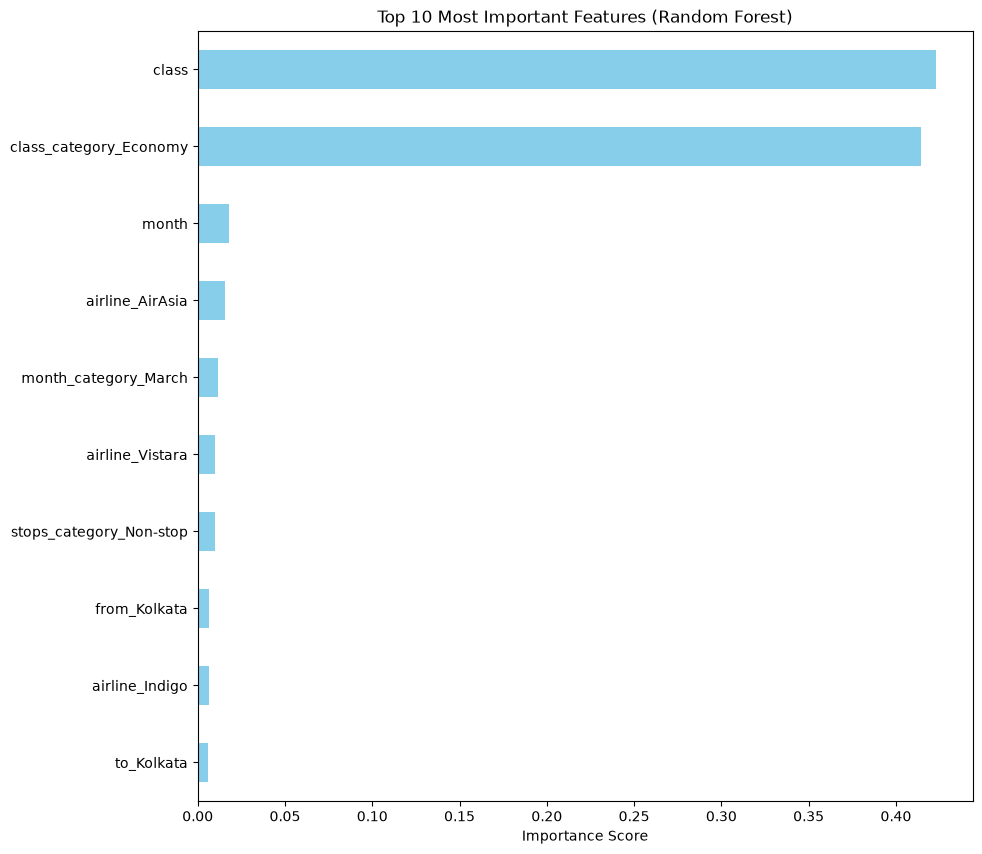

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Plot feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 10))
importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Production training and export: compare both estimators, test on unseen flights, then save the winner.
from pathlib import Path
import ast
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBRegressor

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "app" / "app.py").is_file() and (PROJECT_ROOT.parent / "app" / "app.py").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "Freshly_cleaned.csv",
    PROJECT_ROOT / "Freshly_cleaned.csv",
    Path.cwd() / "Freshly_cleaned.csv",
    Path(r"C:\Users\admin\Downloads\archive (6)\Freshly_cleaned.csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.is_file()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Freshly_cleaned.csv is required. Searched: " + ", ".join(map(str, DATA_CANDIDATES)))

raw = pd.read_csv(DATA_PATH)
if not {"price", "flight_no"}.issubset(raw.columns):
    raise ValueError("Dataset must contain price and flight_no columns.")
groups = raw["flight_no"].astype("string").fillna(pd.Series([f"missing-{i}" for i in range(len(raw))]))
raw = raw.drop(columns=["flight_no", "Unnamed: 0"], errors="ignore")
keep = ~raw.duplicated()
raw = raw.loc[keep].reset_index(drop=True)
groups = groups.loc[keep].reset_index(drop=True)
if raw["price"].isna().any() or (raw["price"] <= 0).any():
    raise ValueError("All training prices must be present and greater than zero.")
features = raw.drop(columns=["price"])
categorical = features.select_dtypes(include=["object", "string", "category"]).columns.tolist()
X = pd.get_dummies(features, columns=categorical, drop_first=True, dtype=np.uint8)
feature_names = list(X.columns)
if not X.columns.is_unique:
    raise ValueError("Training feature names are not unique.")

# Enforce the exact feature order the deployed app will send to the estimator.
app_tree = ast.parse((PROJECT_ROOT / "app" / "app.py").read_text(encoding="utf-8"))
app_features = next(ast.literal_eval(node.value) for node in app_tree.body if isinstance(node, ast.AnnAssign) and isinstance(node.target, ast.Name) and node.target.id == "MODEL_FEATURE_NAMES")
if feature_names != app_features:
    raise ValueError(f"Dataset schema differs from the app. Missing={sorted(set(app_features)-set(feature_names))}; extra={sorted(set(feature_names)-set(app_features))}")
y = np.log1p(raw["price"].astype(np.float64))

# Keep every flight number in a single partition to reduce train/test leakage.
outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
dev_idx, test_idx = next(outer.split(X, y, groups))
X_dev, y_dev, groups_dev = X.iloc[dev_idx], y.iloc[dev_idx], groups.iloc[dev_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=43)
train_idx, val_idx = next(inner.split(X_dev, y_dev, groups_dev))
X_train, y_train = X_dev.iloc[train_idx], y_dev.iloc[train_idx]
X_val, y_val = X_dev.iloc[val_idx], y_dev.iloc[val_idx]

def fare_metrics(estimator, data, target):
    predicted = np.expm1(np.maximum(estimator.predict(data), 0.0))
    actual = np.expm1(target.to_numpy())
    return {"MAE": float(mean_absolute_error(actual, predicted)), "R2": float(r2_score(actual, predicted))}

candidates = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=2, max_features=1.0, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=7, subsample=0.9, colsample_bytree=0.8, min_child_weight=3, reg_lambda=2.0, objective="reg:squarederror", eval_metric="mae", tree_method="hist", early_stopping_rounds=30, random_state=42, n_jobs=-1),
}
validation = {}
for name, estimator in candidates.items():
    if name == "XGBoost":
        estimator.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    else:
        estimator.fit(X_train, y_train)
    validation[name] = fare_metrics(estimator, X_val, y_val)
    print(f"{name} validation: MAE=INR {validation[name]['MAE']:,.2f}; R2={validation[name]['R2']:.4f}")

best_name = min(validation, key=lambda name: validation[name]["MAE"])
selected = candidates[best_name]
params = selected.get_params()
if best_name == "XGBoost":
    params["n_estimators"] = int(selected.best_iteration) + 1
    params["early_stopping_rounds"] = None

# Score the selected configuration once on a flight-grouped holdout not used for selection.
test_model = selected.__class__(**params).fit(X_dev, y_dev)
test = fare_metrics(test_model, X_test, y_test)
print(f"Selected by validation MAE: {best_name}")
print(f"Untouched flight-grouped test: MAE=INR {test['MAE']:,.2f}; R2={test['R2']:.4f}")

# Retrain the winner on all rows and atomically replace the deployment artifact.
production_model = selected.__class__(**params).fit(X, y)
if list(production_model.feature_names_in_) != feature_names:
    raise ValueError("Trained model metadata does not match the app feature schema.")
MODEL_PATH = PROJECT_ROOT / "final_flight_price_rf_model.pkl"
TEMP_MODEL_PATH = MODEL_PATH.with_suffix(MODEL_PATH.suffix + ".tmp")
joblib.dump(production_model, TEMP_MODEL_PATH, compress=3)
TEMP_MODEL_PATH.replace(MODEL_PATH)
print(f"Saved {type(production_model).__name__} trained on {len(X):,} rows and {production_model.n_features_in_} features: {MODEL_PATH}")
print(f"Compressed artifact size: {MODEL_PATH.stat().st_size / (1024 * 1024):.1f} MiB")
print("Perfect prediction cannot be guaranteed; assess the untouched holdout metrics before deployment.")

Random Forest validation: MAE=INR 3,125.76; R2=0.9249
XGBoost validation: MAE=INR 2,581.47; R2=0.9533
Selected by validation MAE: XGBoost
Untouched flight-grouped test: MAE=INR 2,553.91; R2=0.9509
Saved XGBRegressor trained on 299,995 rows and 69 features: f:\plane\final_flight_price_rf_model.pkl
Compressed model size: 1.1 MiB
Perfect prediction cannot be guaranteed; assess the untouched holdout metrics before deployment.
